<a href="https://colab.research.google.com/github/msb24/data-readiness-audit-gate-prototype/blob/main/ModelWatch_Week5_MVP_v1_audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ModelWatch Week 5 MVP
### Rapid prototype for a Support RAG assistant incident workflow

**Prototype question:** Can a small batch of monitoring telemetry turn into an owner-readable incident without overstating what the data proves?

This notebook uses **illustrative data** and a deliberately small rules-based detector. It does not connect to a production system or claim that a knowledge-base update caused the quality decline. The goal is to test the ModelWatch workflow from monitoring data to an incident summary that a product manager can review.


## Prompt 1 outcome
The first vibe-coding prompt asked for the smallest functional version of ModelWatch using only beginner-readable Python, pandas, and matplotlib. I kept the existing Week 4 metrics and limited the MVP to one end-to-end path: load monitoring data, compare a baseline with the current period, flag a material incident, and render a dashboard.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import textwrap
from matplotlib.patches import FancyBboxPatch

pd.set_option('display.max_columns', None)

# Illustrative telemetry for one Support RAG Assistant.
# Raw counts make the metric calculations visible and auditable.
data = pd.DataFrame({
    'date': pd.to_datetime([
        '2026-09-14','2026-09-15','2026-09-16','2026-09-17',
        '2026-09-18','2026-09-19','2026-09-20','2026-09-21'
    ]),
    'period': ['baseline'] * 4 + ['current'] * 4,

    # CSAT evidence
    'rated_conversations': [60, 60, 60, 60, 60, 58, 61, 59],
    'positive_ratings':    [50, 50, 49, 50, 46, 43, 45, 42],

    # Retrieval evidence
    'retrieval_attempts':  [110, 100, 120, 105, 115, 100, 125, 105],
    'retrieval_successes': [100,  90, 107,  95,  94,  80,  98,  80],

    # Citation evidence
    'cited_answers': [90, 92, 88, 91, 89, 90, 87, 88],
    'citation_mismatch_flags': [1, 2, 1, 2, 4, 5, 6, 7],

    # Performance and change context
    'p95_latency_s': [1.8, 1.8, 1.8, 1.8, 1.8, 1.8, 1.8, 1.8],
    'kb_updates': [0, 0, 0, 0, 1, 0, 0, 0]
})

# Daily percentages are for display and charting.
# Period-level metrics will be calculated from pooled raw counts later.
data['csat_pct'] = (
    100 * data['positive_ratings'] / data['rated_conversations']
)

data['retrieval_hit_pct'] = (
    100 * data['retrieval_successes'] / data['retrieval_attempts']
)

data['citation_mismatch_pct'] = (
    100 * data['citation_mismatch_flags'] / data['cited_answers']
)

data.to_csv('modelwatch_monitoring_data.csv', index=False)

data.round(2)

,date,period,rated_conversations,positive_ratings,retrieval_attempts,retrieval_successes,cited_answers,citation_mismatch_flags,p95_latency_s,kb_updates,csat_pct,retrieval_hit_pct,citation_mismatch_pct
0,2026-09-14,baseline,60,50,110,100,90,1,1.8,0,83.33,90.91,1.11
1,2026-09-15,baseline,60,50,100,90,92,2,1.8,0,83.33,90.00,2.17
2,2026-09-16,baseline,60,49,120,107,88,1,1.8,0,81.67,89.17,1.14
3,2026-09-17,baseline,60,50,105,95,91,2,1.8,0,83.33,90.48,2.20
4,2026-09-18,current,60,46,115,94,89,4,1.8,1,76.67,81.74,4.49
5,2026-09-19,current,58,43,100,80,90,5,1.8,0,74.14,80.00,5.56
6,2026-09-20,current,61,45,125,98,87,6,1.8,0,73.77,78.40,6.90
7,2026-09-21,current,59,42,105,80,88,7,1.8,0,71.19,76.19,7.95


## Prompt 2 outcome
The first version could calculate deltas, but that was too easy to trust. I added explicit pipeline checks so the prototype stops when required evidence is missing or malformed. This turns data quality into part of the product behavior instead of a hidden assumption.


In [2]:
REQUIRED_COLUMNS = [
    'date',
    'period',
    'rated_conversations',
    'positive_ratings',
    'retrieval_attempts',
    'retrieval_successes',
    'cited_answers',
    'citation_mismatch_flags',
    'p95_latency_s',
    'kb_updates'
]

def validate_monitoring_data(df):
    problems = []

    # Required fields must exist.
    missing_cols = [c for c in REQUIRED_COLUMNS if c not in df.columns]
    if missing_cols:
        return [f"Missing required columns: {', '.join(missing_cols)}"]

    # Required evidence cannot contain missing values.
    if df[REQUIRED_COLUMNS].isna().any().any():
        bad = (
            df[REQUIRED_COLUMNS]
            .columns[df[REQUIRED_COLUMNS].isna().any()]
            .tolist()
        )
        problems.append(f"Missing values in: {', '.join(bad)}")

    # One monitoring record per date for this small MVP.
    if df['date'].duplicated().any():
        problems.append("Dates must be unique")

    if not df['period'].isin(['baseline', 'current']).all():
        problems.append("Period must be either baseline or current")

    if set(df['period'].unique()) != {'baseline', 'current'}:
        problems.append("Both baseline and current periods are required")

    # Denominators must be usable.
    for column in [
        'rated_conversations',
        'retrieval_attempts',
        'cited_answers'
    ]:
        if (df[column] <= 0).any():
            problems.append(f"{column} must be greater than 0")

    # Counts cannot be negative.
    for column in [
        'positive_ratings',
        'retrieval_successes',
        'citation_mismatch_flags',
        'kb_updates'
    ]:
        if (df[column] < 0).any():
            problems.append(f"{column} cannot be negative")

    # Numerators cannot exceed their denominators.
    if (df['positive_ratings'] > df['rated_conversations']).any():
        problems.append(
            "positive_ratings cannot exceed rated_conversations"
        )

    if (df['retrieval_successes'] > df['retrieval_attempts']).any():
        problems.append(
            "retrieval_successes cannot exceed retrieval_attempts"
        )

    if (df['citation_mismatch_flags'] > df['cited_answers']).any():
        problems.append(
            "citation_mismatch_flags cannot exceed cited_answers"
        )

    if (df['p95_latency_s'] < 0).any():
        problems.append("Latency cannot be negative")

    return problems


validation_problems = validate_monitoring_data(data)

print(
    'PASS - monitoring data is valid'
    if not validation_problems
    else validation_problems
)

PASS - monitoring data is valid


In [3]:
def summarize_period(df, period):
    part = df[df['period'] == period].copy()

    return {
        # CSAT is pooled from raw ratings.
        'rated_conversations':
            int(part['rated_conversations'].sum()),

        'csat_pct':
            100
            * part['positive_ratings'].sum()
            / part['rated_conversations'].sum(),

        # Retrieval gets its own denominator.
        'retrieval_attempts':
            int(part['retrieval_attempts'].sum()),

        'retrieval_hit_pct':
            100
            * part['retrieval_successes'].sum()
            / part['retrieval_attempts'].sum(),

        # Keep both mismatch count and rate.
        'cited_answers':
            int(part['cited_answers'].sum()),

        'citation_mismatch_flags':
            int(part['citation_mismatch_flags'].sum()),

        'citation_mismatch_pct':
            100
            * part['citation_mismatch_flags'].sum()
            / part['cited_answers'].sum(),

        # These are daily p95 observations.
        # Median daily p95 is an honest aggregate label.
        'median_daily_p95_latency_s':
            float(part['p95_latency_s'].median()),

        'kb_updates':
            int(part['kb_updates'].sum())
    }


# Prototype thresholds are intentionally visible.
# They are product rules for testing this MVP, not validated production limits.
THRESHOLDS = {
    'csat_drop_pp': -5.0,
    'retrieval_drop_pp': -7.0,
    'citation_mismatch_increase_pp': 3.0,
    'median_daily_p95_change_s': 0.5
}


def detect_incident(df):

    # Step 1: Trust the evidence before interpreting model health.
    problems = validate_monitoring_data(df)

    if problems:
        return {
            'status': 'BLOCKED',
            'severity': 'Insufficient evidence',
            'problems': problems,
            'observed': [],
            'possible_contributors': [],
            'owner': 'Data / telemetry owner',
            'question':
                'Fix the monitoring input before interpreting model behavior.'
        }

    # Step 2: Compare historical baseline with the current period.
    baseline = summarize_period(df, 'baseline')
    current = summarize_period(df, 'current')

    deltas = {
        'csat_pp':
            current['csat_pct'] - baseline['csat_pct'],

        'retrieval_pp':
            current['retrieval_hit_pct']
            - baseline['retrieval_hit_pct'],

        'citation_mismatch_pp':
            current['citation_mismatch_pct']
            - baseline['citation_mismatch_pct'],

        'latency_s':
            current['median_daily_p95_latency_s']
            - baseline['median_daily_p95_latency_s']
    }

    # Step 3: Count meaningful quality changes.
    quality_breaches = []

    if deltas['csat_pp'] <= THRESHOLDS['csat_drop_pp']:
        quality_breaches.append('CSAT')

    if deltas['retrieval_pp'] <= THRESHOLDS['retrieval_drop_pp']:
        quality_breaches.append('retrieval')

    if (
        deltas['citation_mismatch_pp']
        >= THRESHOLDS['citation_mismatch_increase_pp']
    ):
        quality_breaches.append('citation mismatch')

    # Slower latency is a problem.
    # Faster latency should not trigger an incident.
    latency_breach = (
        deltas['latency_s']
        >= THRESHOLDS['median_daily_p95_change_s']
    )

    # Step 4: Create an inspectable incident state.
    if len(quality_breaches) >= 2:
        severity = 'High'

    elif len(quality_breaches) == 1 or latency_breach:
        severity = 'Medium'

    else:
        severity = 'No incident'

    status = (
        'READY FOR OWNER REVIEW'
        if severity in ['High', 'Medium']
        else 'NO HANDOFF NEEDED'
    )

    observed = [
        (
            f"CSAT {current['csat_pct']:.1f}% "
            f"({deltas['csat_pp']:+.1f} pp vs baseline)"
        ),
        (
            f"Retrieval hit rate {current['retrieval_hit_pct']:.1f}% "
            f"({deltas['retrieval_pp']:+.1f} pp)"
        ),
        (
            f"Citation mismatch rate "
            f"{current['citation_mismatch_pct']:.1f}% "
            f"({deltas['citation_mismatch_pp']:+.1f} pp)"
        ),
        (
            f"Median daily p95 latency "
            f"{current['median_daily_p95_latency_s']:.1f}s "
            f"({deltas['latency_s']:+.1f}s)"
        )
    ]

    possible = []

    if (
        current['kb_updates'] > 0
        and severity in ['High', 'Medium']
    ):
        possible.append(
            'A knowledge-base update occurred during the current period. '
            'Review timing and changed documents before attributing cause.'
        )

    elif severity in ['High', 'Medium']:
        possible.append(
            'The current telemetry does not identify a specific contributor. '
            'Review traces and recent changes.'
        )

    question = (
        "Why did the Support RAG assistant's quality fall this week?"
        if severity != 'No incident'
        else "Is the Support RAG assistant stable this week?"
    )

    return {
        'status': status,
        'severity': severity,
        'baseline': baseline,
        'current': current,
        'deltas': deltas,
        'observed': observed,
        'possible_contributors': possible,
        'owner':
            'AI Product + Support Operations'
            if severity != 'No incident'
            else 'No handoff needed',
        'question': question
    }


incident = detect_incident(data)
incident

{'status': 'READY FOR OWNER REVIEW',
 'severity': 'High',
 'baseline': {'rated_conversations': 240,
  'csat_pct': np.float64(82.91666666666667),
  'retrieval_attempts': 435,
  'retrieval_hit_pct': np.float64(90.11494252873563),
  'cited_answers': 361,
  'citation_mismatch_flags': 6,
  'citation_mismatch_pct': np.float64(1.6620498614958448),
  'median_daily_p95_latency_s': 1.8,
  'kb_updates': 0},
 'current': {'rated_conversations': 238,
  'csat_pct': np.float64(73.94957983193277),
  'retrieval_attempts': 445,
  'retrieval_hit_pct': np.float64(79.10112359550561),
  'cited_answers': 354,
  'citation_mismatch_flags': 22,
  'citation_mismatch_pct': np.float64(6.214689265536723),
  'median_daily_p95_latency_s': 1.8,
  'kb_updates': 1},
 'deltas': {'csat_pp': np.float64(-8.967086834733905),
  'retrieval_pp': np.float64(-11.013818933230013),
  'citation_mismatch_pp': np.float64(4.552639404040878),
  'latency_s': 0.0},
 'observed': ['CSAT 73.9% (-9.0 pp vs baseline)',
  'Retrieval hit rate 79.

## Prompt 3 outcome
I asked ChatGPT to try to break the prototype instead of only polishing the happy path. The tests below cover a degraded period, stable behavior, incomplete evidence, and a one-signal warning. These cases make it harder to accidentally design the logic around one convenient example.


In [4]:
def run_tests():
    results = []

    # 1. Known degraded scenario should be High.
    r1 = detect_incident(data)
    results.append(
        ('degraded data', 'High', r1['severity'])
    )

    # 2. Copy baseline evidence into the current period.
    # This should produce No incident.
    stable = data.copy()
    current_mask = stable['period'] == 'current'

    baseline_rows = (
        data[data['period'] == 'baseline']
        .reset_index(drop=True)
    )

    evidence_columns = [
        'rated_conversations',
        'positive_ratings',
        'retrieval_attempts',
        'retrieval_successes',
        'cited_answers',
        'citation_mismatch_flags',
        'p95_latency_s'
    ]

    for column in evidence_columns:
        stable.loc[current_mask, column] = (
            baseline_rows[column].to_numpy()
        )

    r2 = detect_incident(stable)

    results.append(
        ('stable data', 'No incident', r2['severity'])
    )

    # 3. A zero denominator means the evidence is unusable.
    incomplete = data.copy()
    incomplete.loc[
        incomplete.index[-1],
        'retrieval_attempts'
    ] = 0

    r3 = detect_incident(incomplete)

    results.append(
        (
            'invalid denominator',
            'Insufficient evidence',
            r3['severity']
        )
    )

    # 4. Keep only the CSAT deterioration.
    # One material quality signal should be Medium.
    one_signal = data.copy()
    current_mask = one_signal['period'] == 'current'

    for column in [
        'retrieval_attempts',
        'retrieval_successes',
        'cited_answers',
        'citation_mismatch_flags',
        'p95_latency_s'
    ]:
        one_signal.loc[current_mask, column] = (
            baseline_rows[column].to_numpy()
        )

    r4 = detect_incident(one_signal)

    results.append(
        ('single quality signal', 'Medium', r4['severity'])
    )

    table = pd.DataFrame(
        results,
        columns=['test_case', 'expected', 'actual']
    )

    table['pass'] = (
        table['expected'] == table['actual']
    )

    assert table['pass'].all(), table

    return table


run_tests()

,test_case,expected,actual,pass
0,degraded data,High,High,True
1,stable data,No incident,No incident,True
2,invalid denominator,Insufficient evidence,Insufficient evidence,True
3,single quality signal,Medium,Medium,True


## Prompt 4 outcome
The final prompt focused on trust and continuity with the Figma prototype. I asked for measured signals to stay visually separate from possible contributors, for the owner handoff to remain draft-only, and for the screenshot to use the same ModelWatch visual language. The dashboard below is the final prototype draft.


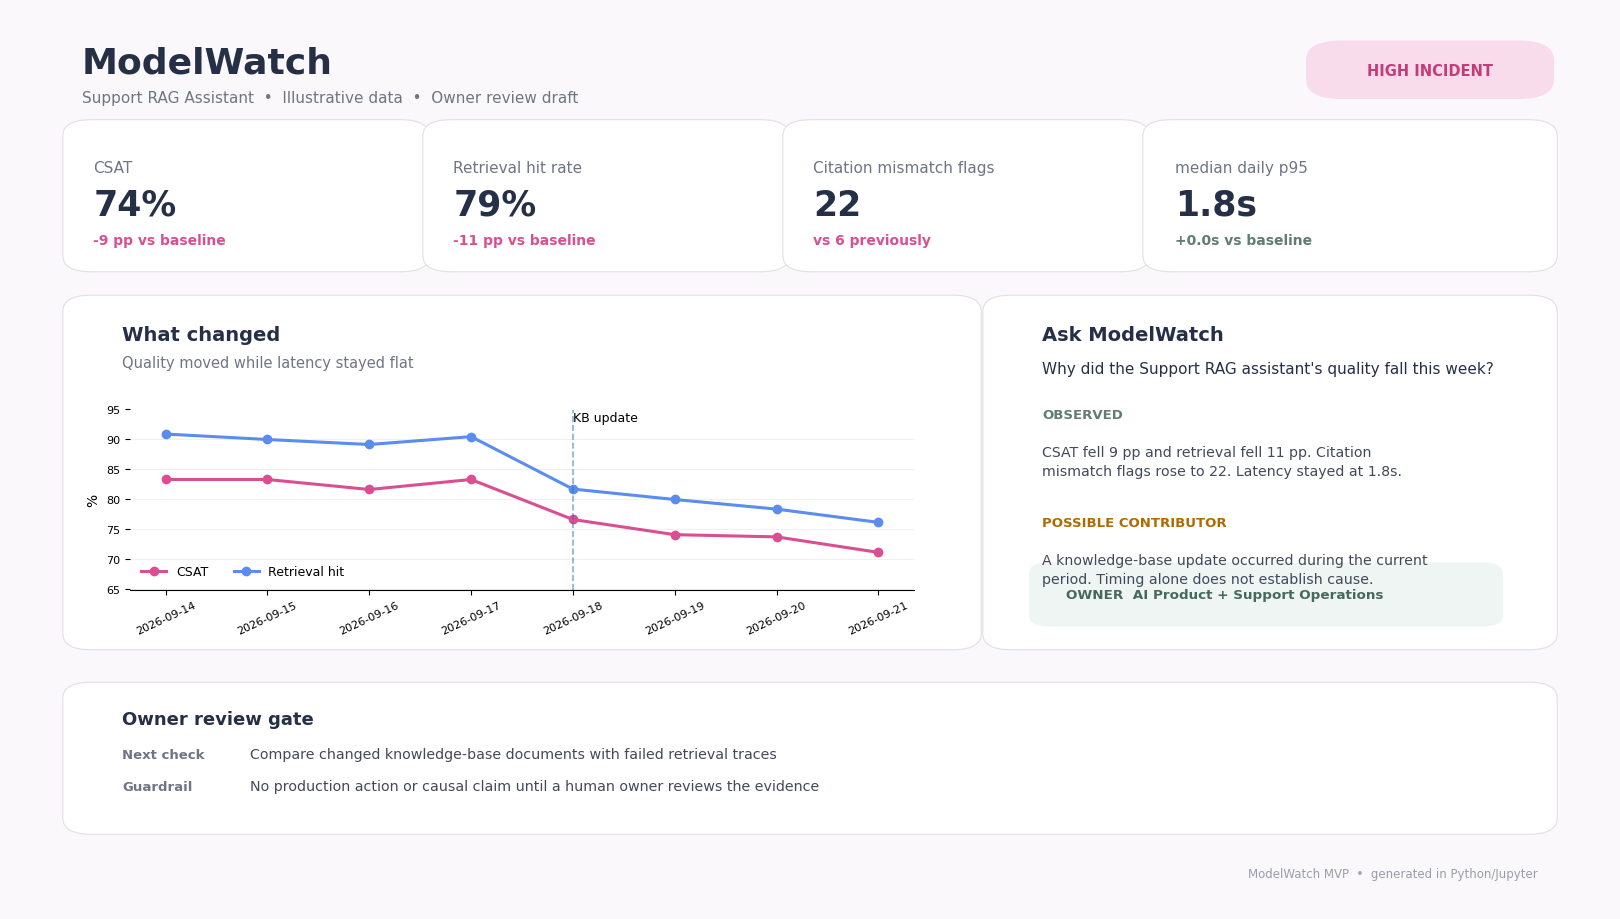

In [5]:
def add_card(ax, x, y, w, h, title, value, detail, accent='#D94F91'):
    card = FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.012,rounding_size=0.018',
                          linewidth=0.8, edgecolor='#E4DEE7', facecolor='white')
    ax.add_patch(card)
    ax.text(x + 0.035*w, y + h*0.72, title, fontsize=11, color='#6E7585', weight='medium', va='center')
    ax.text(x + 0.035*w, y + h*0.43, value, fontsize=25, color='#253047', weight='bold', va='center')
    ax.text(x + 0.035*w, y + h*0.16, detail, fontsize=10, color=accent, weight='semibold', va='center')


def make_dashboard(df, incident, save_path='modelwatch_prototype.png'):
    fig = plt.figure(figsize=(16, 9), facecolor='#FAF8FB')
    ax = fig.add_axes([0, 0, 1, 1])
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis('off')

    # Header
    ax.text(0.045, 0.94, 'ModelWatch', fontsize=26, weight='bold', color='#253047', va='center')
    ax.text(0.045, 0.902, 'Support RAG Assistant  •  Illustrative data  •  Owner review draft',
            fontsize=11, color='#6E7585', va='center')
    sev_color = '#C33C78' if incident['severity'] == 'High' else '#A56A00'
    pill = FancyBboxPatch((0.82, 0.91), 0.135, 0.045, boxstyle='round,pad=0.01,rounding_size=0.022',
                         linewidth=0, facecolor='#F8DCEB')
    ax.add_patch(pill)
    ax.text(0.8875, 0.932, f"{incident['severity'].upper()} INCIDENT", fontsize=10.5,
            color=sev_color, ha='center', va='center', weight='bold')

    cur = incident['current']; d = incident['deltas']
    add_card(ax, 0.045, 0.72, 0.205, 0.145, 'CSAT', f"{cur['csat_pct']:.0f}%", f"{d['csat_pp']:+.0f} pp vs baseline")
    add_card(ax, 0.27, 0.72, 0.205, 0.145, 'Retrieval hit rate', f"{cur['retrieval_hit_pct']:.0f}%", f"{d['retrieval_pp']:+.0f} pp vs baseline")
    add_card(ax, 0.495, 0.72, 0.205, 0.145, 'Citation mismatch flags', f"{cur['citation_mismatch_flags']}", f"vs {incident['baseline']['citation_mismatch_flags']} previously")
    add_card(ax, 0.72, 0.72, 0.235, 0.145, 'median daily p95', f"{cur['median_daily_p95_latency_s']:.1f}s", f"{d['latency_s']:+.1f}s vs baseline", accent='#5F7D70')

    # Trend chart card
    chart_card = FancyBboxPatch((0.045, 0.30), 0.55, 0.37, boxstyle='round,pad=0.012,rounding_size=0.018',
                                linewidth=0.8, edgecolor='#E4DEE7', facecolor='white')
    ax.add_patch(chart_card)
    ax.text(0.07, 0.632, 'What changed', fontsize=14, color='#253047', weight='bold')
    ax.text(0.07, 0.602, 'Quality moved while latency stayed flat', fontsize=10.5, color='#6E7585')

    chart = fig.add_axes([0.075, 0.355, 0.49, 0.20], facecolor='white')
    chart.plot(df['date'], df['csat_pct'], marker='o', linewidth=2.2, color='#D94F91', label='CSAT')
    chart.plot(df['date'], df['retrieval_hit_pct'], marker='o', linewidth=2.2, color='#5A8DEE', label='Retrieval hit')
    chart.axvline(pd.Timestamp('2026-09-18'), linestyle='--', linewidth=1.2, alpha=0.55)
    chart.text(pd.Timestamp('2026-09-18'), 92.5, 'KB update', fontsize=9, ha='left', va='bottom')
    chart.set_ylim(65, 95)
    chart.set_ylabel('%')
    chart.grid(axis='y', alpha=0.18)
    chart.spines[['top','right','left']].set_visible(False)
    chart.tick_params(axis='x', labelrotation=25, labelsize=8)
    chart.tick_params(axis='y', labelsize=8)
    chart.legend(frameon=False, fontsize=9, ncol=2, loc='lower left')

    # Evidence and owner review card
    right = FancyBboxPatch((0.62, 0.30), 0.335, 0.37, boxstyle='round,pad=0.012,rounding_size=0.018',
                           linewidth=0.8, edgecolor='#E4DEE7', facecolor='white')
    ax.add_patch(right)
    ax.text(0.645, 0.632, 'Ask ModelWatch', fontsize=14, color='#253047', weight='bold')
    ax.text(0.645, 0.595, incident['question'], fontsize=11, color='#253047', weight='medium')

    ax.text(0.645, 0.545, 'OBSERVED', fontsize=9.5, color='#5F7D70', weight='bold')
    obs = f"CSAT fell {abs(d['csat_pp']):.0f} pp and retrieval fell {abs(d['retrieval_pp']):.0f} pp. "           f"Citation mismatch flags rose to {cur['citation_mismatch_flags']}. Latency stayed at {cur['median_daily_p95_latency_s']:.1f}s."
    ax.text(0.645, 0.515, textwrap.fill(obs, 53), fontsize=10.2, color='#41495B', va='top', linespacing=1.45)

    ax.text(0.645, 0.425, 'POSSIBLE CONTRIBUTOR', fontsize=9.5, color='#B06A00', weight='bold')
    poss = 'A knowledge-base update occurred during the current period. Timing alone does not establish cause.'
    ax.text(0.645, 0.395, textwrap.fill(poss, 53), fontsize=10.2, color='#41495B', va='top', linespacing=1.45)

    owner_box = FancyBboxPatch((0.645, 0.322), 0.28, 0.055, boxstyle='round,pad=0.008,rounding_size=0.012',
                               linewidth=0, facecolor='#EEF5F2')
    ax.add_patch(owner_box)
    ax.text(0.66, 0.349, 'OWNER  AI Product + Support Operations', fontsize=9.7,
            color='#46695C', weight='bold', va='center')

    # Footer / review gate
    footer = FancyBboxPatch((0.045, 0.095), 0.91, 0.145, boxstyle='round,pad=0.012,rounding_size=0.018',
                            linewidth=0.8, edgecolor='#E4DEE7', facecolor='white')
    ax.add_patch(footer)
    ax.text(0.07, 0.205, 'Owner review gate', fontsize=13, color='#253047', weight='bold')
    ax.text(0.07, 0.168, 'Next check', fontsize=9.5, color='#6E7585', weight='bold')
    ax.text(0.15, 0.168, 'Compare changed knowledge-base documents with failed retrieval traces', fontsize=10.3, color='#41495B')
    ax.text(0.07, 0.132, 'Guardrail', fontsize=9.5, color='#6E7585', weight='bold')
    ax.text(0.15, 0.132, 'No production action or causal claim until a human owner reviews the evidence', fontsize=10.3, color='#41495B')
    ax.text(0.955, 0.035, 'ModelWatch MVP  •  generated in Python/Jupyter', fontsize=8.5, color='#9A9EAA', ha='right')

    plt.savefig(save_path, dpi=180, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()

make_dashboard(data, incident)

## What this prototype proves and what it does not

The notebook proves that ModelWatch's core Week 4 workflow can be represented with a tiny, inspectable data pipeline. It can validate telemetry, summarize baseline versus current behavior, classify incident severity, and produce an owner-review draft. The causal explanation remains deliberately limited. A production version would replace the CSV with real evaluation traces and monitoring connectors, use stronger statistical or ML drift detection, and add a reviewed generative explanation step only after the evidence pipeline is reliable.
